# Data Transformation

**Manual Feature Engineering: Daily Return, Historical Volatility**

Author: Pete King

This notebook computes additional financial features for all sector ETFs, specifically daily return and near-term historical volatility.  We also calculate the training labels: a return and volatility forecast over a near-term outlook.


In [1]:
import numpy as np
import pandas as pd

import data_prep as dp

ETF_DATA_FILE = 'etf_raw_data.csv'
WINDOW_SIZE = 5  # No. business days for historical volatility feature
OUTLOOK = 5  # Future outlook (no. business days) for predicted volatility label

## I. Import data

In [2]:
etf_df = pd.read_csv(
    ETF_DATA_FILE,
    index_col='date',
    parse_dates=True
)
tickers = etf_df.columns

In [3]:
# Find starting date for each asset for future reference
starting_date = {}
for ticker in tickers:
    starting_date[ticker] = etf_df[ticker].dropna().index.min()
sorted([(k, v) for k, v in starting_date.items()], key=lambda i:i[1])

[('SPY', Timestamp('1993-01-29 00:00:00')),
 ('XLB', Timestamp('1998-12-22 00:00:00')),
 ('XLE', Timestamp('1998-12-22 00:00:00')),
 ('XLF', Timestamp('1998-12-22 00:00:00')),
 ('XLI', Timestamp('1998-12-22 00:00:00')),
 ('XLK', Timestamp('1998-12-22 00:00:00')),
 ('XLP', Timestamp('1998-12-22 00:00:00')),
 ('XLU', Timestamp('1998-12-22 00:00:00')),
 ('XLV', Timestamp('1998-12-22 00:00:00')),
 ('XLY', Timestamp('1998-12-22 00:00:00')),
 ('QQQ', Timestamp('1999-03-10 00:00:00')),
 ('IWM', Timestamp('2000-05-26 00:00:00')),
 ('IEF', Timestamp('2002-07-30 00:00:00')),
 ('LQD', Timestamp('2002-07-30 00:00:00')),
 ('TLT', Timestamp('2002-07-30 00:00:00')),
 ('TIP', Timestamp('2003-12-05 00:00:00')),
 ('GLD', Timestamp('2004-11-18 00:00:00')),
 ('BND', Timestamp('2007-04-10 00:00:00')),
 ('HYG', Timestamp('2007-04-11 00:00:00')),
 ('BIL', Timestamp('2007-05-30 00:00:00')),
 ('XLRE', Timestamp('2015-10-08 00:00:00'))]

## II. Compute Features and Labels

### Daily return (feature) and future return (label)

Return represents a change in the price of an asset.  Daily return is given by the formula:

*return_t = log(price_t / price_t-1)*

While the future return forecast (for 5 business days) will be computed as:

*return_target_t = log(price_t+5 / price_t)*

If we think of return for an asset as a random variable R, we can think of the asset's historical volatility as the standard deviation of its returns.  In accordance with established financial practice and empirical evidence, we can make a simplifying assumption that the expected return (i.e., long-term average) for any asset is zero.  The "zero mean" assumption for returns allows us to compute volatility using the following formula:

*volatility = sqrt(sum(R_i^2) / n)*

where *n* is the number of business days in the historical window.  We use *n=5* for a computation of both the historical volatility feature and a future volatility label.  This decision was made based on literature that shows 1) the past 5 days of volatility are highly correlated with future volatility, and 2) much like the weather, volatility outlooks beyond 2 weeks become challenging.


In [4]:
ret_d, ret_w = {}, {}
for ticker in tickers:
    # Compute daily return (feature)
    ret_d[ticker + '_ret'] = (
        np.log(etf_df[ticker].values / etf_df[ticker].shift(1).values)
    )
    # Compute future weekly return (label)
    ret_w[ticker + '_ret_target'] = (
        np.log(etf_df[ticker].shift(-OUTLOOK).values / etf_df[ticker].values)
    )
pd.DataFrame(ret_d, index=etf_df.index)

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_ret,XLE_ret,XLF_ret,XLI_ret,XLK_ret,XLP_ret,XLRE_ret,XLU_ret,XLV_ret,XLY_ret
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007088,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002116,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010516,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004176,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13,0.000328,-0.000951,-0.013021,-0.001892,-0.001046,-0.003320,-0.003691,-0.005945,-0.005676,-0.001985,...,-0.009912,0.003298,0.001228,-0.003577,-0.007574,0.005799,0.002607,0.009844,-0.002467,-0.005936
2026-03-16,0.000000,0.003800,-0.000890,0.003152,0.004488,0.009405,0.004796,0.011155,0.010125,0.003156,...,0.004260,0.003460,0.008351,0.008527,0.014370,0.002828,0.007780,0.006368,0.008112,0.012015
2026-03-17,0.000109,0.002030,-0.002523,0.004521,0.001769,0.006307,0.005597,0.004868,0.002627,0.003505,...,0.002426,0.010480,0.005260,0.002646,0.005461,-0.003300,0.003283,-0.002754,-0.009114,0.008697


In [5]:
# Make volatility features & targets using return data
vol_h, vol_f = {}, {}
for ticker in tickers:
    etf_return = pd.Series(ret_d[ticker + '_ret'], index=etf_df.index)
    # Compute historical volatility (feature)
    vol_h[ticker + '_h-vol'] = (
    etf_return.rolling(WINDOW_SIZE).apply(dp.volatility, raw=True).values
    )
    # Compute future volatility (label)
    vol_f[ticker + '_f-vol_target'] = (
        etf_return.shift(-OUTLOOK).rolling(OUTLOOK).apply(
            dp.volatility, raw=True
        ).values
    )
etf_df = pd.concat(
    [
        pd.DataFrame(ret_d, index=etf_df.index),
        pd.DataFrame(vol_h, index=etf_df.index),
        pd.DataFrame(ret_w, index=etf_df.index),
        pd.DataFrame(vol_f, index=etf_df.index)
    ], axis=1
)
etf_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_f-vol_target,XLE_f-vol_target,XLF_f-vol_target,XLI_f-vol_target,XLK_f-vol_target,XLP_f-vol_target,XLRE_f-vol_target,XLU_f-vol_target,XLV_f-vol_target,XLY_f-vol_target
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007088,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002116,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010516,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004176,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13,0.000328,-0.000951,-0.013021,-0.001892,-0.001046,-0.003320,-0.003691,-0.005945,-0.005676,-0.001985,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-16,0.000000,0.003800,-0.000890,0.003152,0.004488,0.009405,0.004796,0.011155,0.010125,0.003156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-17,0.000109,0.002030,-0.002523,0.004521,0.001769,0.006307,0.005597,0.004868,0.002627,0.003505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


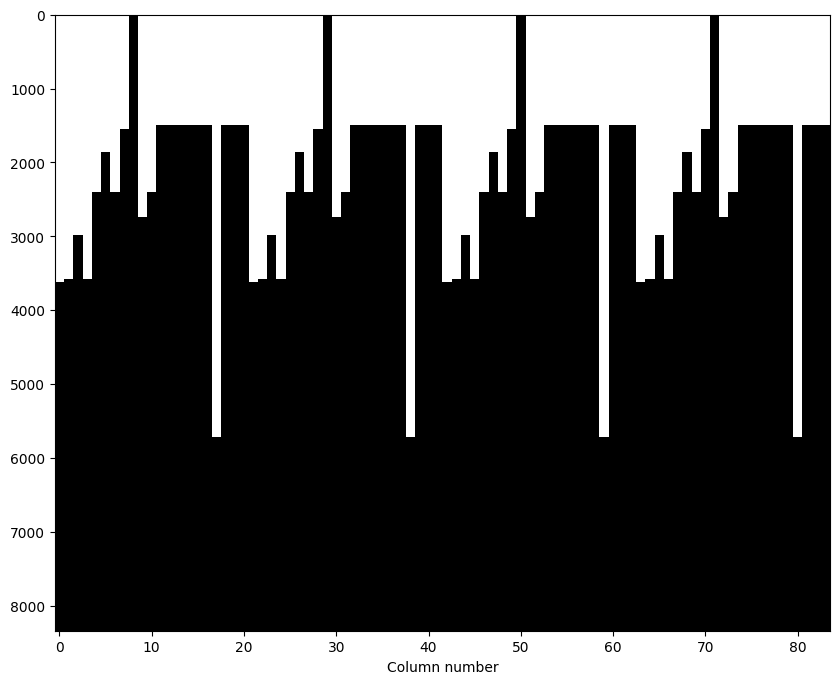

In [6]:
dp.view_nan(etf_df);

In [7]:
etf_df.to_csv('etf_labelled.csv', index_label='date')

In [8]:
# Save tickers for convenience later
ticker_df = pd.DataFrame({'Ticker': [ticker for ticker in tickers]})
ticker_df.to_csv('tickers.csv', index=False)